In [ ]:
# Benchmark: AI-generated vs Real image classification with a deep + dense CNN

import random
import time
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    balanced_accuracy_score,
)
from datasets import load_dataset
from huggingface_hub import login

SEED = 42
BATCH_SIZE = 8
IMG_HEIGHT = 160
IMG_WIDTH = 160
EPOCHS = 20
LEARNING_RATE = 1e-4

# Hugging Face dataset repo.
# Expected schema:
#   image -> image data
#   label -> 1 for real, 0 for fake
DATASET_REPO = "ShreyashDhoot/AI_vs_Real"

# Paste your Hugging Face access token here, or set it from an environment variable.
HF_TOKEN = ""

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if HF_TOKEN and HF_TOKEN != "PASTE_YOUR_HF_ACCESS_TOKEN_HERE":
    login(token=HF_TOKEN)
    print("Hugging Face token configured.")
else:
    print("No Hugging Face token configured; loading will use anonymous access.")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
else:
    print("No GPU detected; training will run on CPU and may be slow.")

print("TensorFlow version:", tf.__version__)
print("Hugging Face dataset:", DATASET_REPO)

Hugging Face token configured.
GPUs detected: 1
TensorFlow version: 2.19.0
Hugging Face dataset: ShreyashDhoot/AI_vs_Real


In [10]:
# Data loading and split from Hugging Face Hub

def load_dataset_with_retry(repo_id, token=None, max_attempts=5, initial_delay=5):
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            return load_dataset(repo_id, token=token)
        except Exception as exc:
            last_error = exc
            message = str(exc)
            if "429" not in message and "Too Many Requests" not in message:
                raise
            if attempt == max_attempts:
                break
            delay = initial_delay * attempt
            print(f"Hugging Face rate limited the request. Retrying in {delay} seconds... (attempt {attempt}/{max_attempts})")
            time.sleep(delay)
    raise last_error

loaded_dataset = load_dataset_with_retry(DATASET_REPO, token=HF_TOKEN if HF_TOKEN != "PASTE_YOUR_HF_ACCESS_TOKEN_HERE" else None)

# Support either a single Dataset or a DatasetDict with named splits.
if hasattr(loaded_dataset, "keys"):
    if "train" in loaded_dataset:
        raw_dataset = loaded_dataset["train"]
    else:
        first_split_name = next(iter(loaded_dataset.keys()))
        raw_dataset = loaded_dataset[first_split_name]
else:
    raw_dataset = loaded_dataset

# Ensure labels are present and images are accessible as PIL images.
required_columns = {"image", "label"}
if not required_columns.issubset(set(raw_dataset.column_names)):
    raise ValueError("The dataset must contain 'image' and 'label' columns.")

# Create train/validation/test splits from the HF dataset without materializing images.
if not hasattr(raw_dataset, "train_test_split"):
    raise TypeError("Expected a map-style Hugging Face Dataset. Streaming datasets are not supported in this notebook because they cannot be safely split without extra buffering.")

split_1 = raw_dataset.train_test_split(test_size=0.2, seed=SEED)
train_raw = split_1["train"]
remaining_raw = split_1["test"]

split_2 = remaining_raw.train_test_split(test_size=0.5, seed=SEED)
val_raw = split_2["train"]
test_raw = split_2["test"]

class_names = ["fake", "real"]

print("Dataset loaded from:", DATASET_REPO)
print("Train size:", len(train_raw))
print("Validation size:", len(val_raw))
print("Test size:", len(test_raw))
print("Label mapping: 0 -> fake, 1 -> real")

# Build tf.data pipelines that decode and resize one image at a time.
def split_generator(hf_split):
    for example in hf_split:
        image = example["image"].convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
        image = np.asarray(image, dtype=np.uint8)
        label = np.int32(example["label"])
        yield image, label

output_signature = (
    tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.uint8),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

AUTOTUNE = tf.data.AUTOTUNE


def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


base_train_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(train_raw),
    output_signature=output_signature,
).map(preprocess_train, num_parallel_calls=AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(val_raw),
    output_signature=output_signature,
).map(preprocess_eval, num_parallel_calls=AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(test_raw),
    output_signature=output_signature,
).map(preprocess_eval, num_parallel_calls=AUTOTUNE)

# Explicit epoch sizing avoids "input ran out of data" warnings with generator-backed datasets.
train_steps_per_epoch = (len(train_raw) + BATCH_SIZE - 1) // BATCH_SIZE
val_steps = (len(val_raw) + BATCH_SIZE - 1) // BATCH_SIZE
test_steps = (len(test_raw) + BATCH_SIZE - 1) // BATCH_SIZE

train_ds = base_train_ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True).repeat().batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Train steps/epoch:", train_steps_per_epoch)
print("Validation steps:", val_steps)
print("Test steps:", test_steps)

Dataset loaded from: ShreyashDhoot/AI_vs_Real
Train size: 144381
Validation size: 18048
Test size: 18048
Label mapping: 0 -> fake, 1 -> real
Train steps/epoch: 18048
Validation steps: 2256
Test steps: 2256


In [11]:
# Compute class weights and analyze class imbalance
train_labels_only = np.asarray(train_raw["label"], dtype=np.int32)
train_label_counts = np.bincount(train_labels_only, minlength=2)
train_total = int(train_label_counts.sum())
if train_total == 0:
    raise ValueError("No training samples found in the Hugging Face dataset.")

# Keras class_weight expects mapping class_index -> weight
class_weight = {
    label: train_total / (len(class_names) * max(int(count), 1))
    for label, count in enumerate(train_label_counts)
}

print("Class distribution (train):", {"fake": int(train_label_counts[0]), "real": int(train_label_counts[1])})
print("Class weights:", class_weight)

# Detailed class imbalance analysis
imbalance_ratio = train_label_counts[1] / train_label_counts[0] if train_label_counts[0] > 0 else float('inf')
print(f"Imbalance ratio (real/fake): {imbalance_ratio:.2f}")
print(f"Fake samples: {train_label_counts[0]} ({100*train_label_counts[0]/train_total:.1f}%)")
print(f"Real samples: {train_label_counts[1]} ({100*train_label_counts[1]/train_total:.1f}%)")

Class distribution (train): {'fake': 86393, 'real': 57988}
Class weights: {0: 0.8356058939960413, 1: 1.244921363040629}
Imbalance ratio (real/fake): 0.67
Fake samples: 86393 (59.8%)
Real samples: 57988 (40.2%)


In [12]:
# Focal Loss implementation for handling class imbalance
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE, name="focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_true = tf.reshape(y_true, (-1, 1))
        y_pred = tf.cast(y_pred, tf.float32)

        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())

        # Binary cross entropy
        bce = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)

        # Focal loss: alpha * (1 - p_t)^gamma * bce
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        focal_loss = focal_weight * bce

        return tf.reduce_mean(focal_loss)


# Build a deep and dense CNN with Residual Connections
# Note: augmentation is applied in tf.data pipeline for keras/tf compatibility.
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = inputs

# Block 1 with enhanced regularization
x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(16, 3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Block 2 with residual connection
shortcut_2 = tf.keras.layers.Conv2D(32, 1, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, shortcut_2])
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Block 3 with residual connection
shortcut_3 = tf.keras.layers.Conv2D(64, 1, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, shortcut_3])
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)

# Block 4 with residual connection
shortcut_4 = tf.keras.layers.Conv2D(128, 1, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(128, 3, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, shortcut_4])
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)

# Dense head with tuned regularization
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.45)(x)
x = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.35)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs, name="residual_cnn_focal")

# Compile with Focal Loss and aggressive learning rate schedule
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

print("Model with Residual Connections and Focal Loss:")
model.summary()

Model with Residual Connections and Focal Loss:


Model: "residual_cnn_focal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 160, 160,  │        448 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 160, 160,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │         64 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 160, 160,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 80, 80,    │          0 │ re_lu_4[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 80, 80,    │          0 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 80, 80,    │      4,640 │ dropout_6[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 80, 80,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 80, 80,    │        544 │ dropout_6[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 80, 80,    │          0 │ add_3[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 40, 40,    │          0 │ re_lu_5[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 40, 40,    │          0 │ max_pooling2d_5[

 Total params: 332,017 (1.27 MB)

 Trainable params: 330,673 (1.26 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [13]:
# Train the model with advanced learning rate scheduling
# Warm-up learning rate schedule
def lr_schedule_warmup(epoch, lr):
    warmup_epochs = 2
    if epoch < warmup_epochs:
        return LEARNING_RATE * (epoch + 1) / warmup_epochs
    return lr

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        patience=7,
        restore_best_weights=True,
        verbose=1,
        mode="max",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
        mode="max",
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule_warmup, verbose=0),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=train_steps_per_epoch,
    validation_steps=val_steps,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
18048/18048 ━━━━━━━━━━━━━━━━━━━━ 501s 26ms/step - accuracy: 0.5640 - loss: 0.1332 - pr_auc: 0.4515 - precision: 0.4581 - recall: 0.4674 - roc_auc: 0.5731 - val_accuracy: 0.6006 - val_loss: 0.1216 - val_pr_auc: 0.5434 - val_precision: 0.1250 - val_recall: 1.3885e-04 - val_roc_auc: 0.6963 - learning_rate: 5.0000e-05
Epoch 2/20
18048/18048 ━━━━━━━━━━━━━━━━━━━━ 474s 26ms/step - accuracy: 0.6236 - loss: 0.0645 - pr_auc: 0.5171 - precision: 0.5329 - recall: 0.5072 - roc_auc: 0.6592 - val_accuracy: 0.6151 - val_loss: 0.0455 - val_pr_auc: 0.5778 - val_precision: 0.6150 - val_recall: 0.0947 - val_roc_auc: 0.7239 - learning_rate: 1.0000e-04
Epoch 3/20
18048/18048 ━━━━━━━━━━━━━━━━━━━━ 502s 28ms/step - accuracy: 0.6561 - loss: 0.0419 - pr_auc: 0.5669 - precision: 0.5691 - recall: 0.5919 - roc_auc: 0.7075 - val_accuracy: 0.6436 - val_loss: 0.0398 - val_pr_auc: 0.5990 - val_precision: 0.6440 - val_recall: 0.2391 - val_roc_auc: 0.7448 - learning_rate: 1.0000e-04
Epoch 4/20
18048/18048 ━━━━

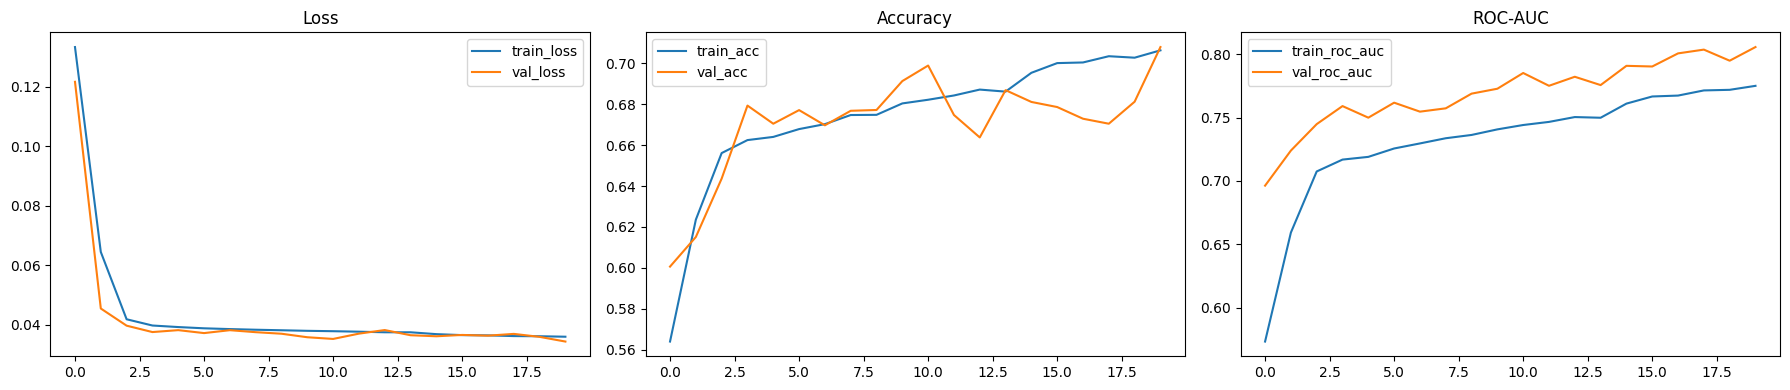

In [14]:
# Plot training curves
hist = history.history

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist.get("loss", []), label="train_loss")
axes[0].plot(hist.get("val_loss", []), label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist.get("accuracy", []), label="train_acc")
axes[1].plot(hist.get("val_accuracy", []), label="val_acc")
axes[1].set_title("Accuracy")
axes[1].legend()

axes[2].plot(hist.get("roc_auc", []), label="train_roc_auc")
axes[2].plot(hist.get("val_roc_auc", []), label="val_roc_auc")
axes[2].set_title("ROC-AUC")
axes[2].legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluate on test set with optimal threshold tuning

y_true = []
y_prob = []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0).flatten()
    y_prob.extend(probs.tolist())
    y_true.extend(y_batch.numpy().flatten().astype(int).tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Optimal threshold tuning: search for best F1 score
thresholds = np.arange(0.1, 0.95, 0.01)
f1_scores = []
precision_scores = []
recall_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_true, y_pred_thresh, zero_division=0)
    prec = precision_score(y_true, y_pred_thresh, zero_division=0)
    rec = recall_score(y_true, y_pred_thresh, zero_division=0)
    f1_scores.append(f1)
    precision_scores.append(prec)
    recall_scores.append(rec)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"=== Optimal Threshold Analysis ===")
print(f"Optimal threshold: {optimal_threshold:.2f} (F1={optimal_f1:.4f})")
print(f"Default threshold (0.5): F1={f1_score(y_true, (y_prob >= 0.5).astype(int), zero_division=0):.4f}")

# Use optimal threshold for predictions
y_pred = (y_prob >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "roc_auc": roc_auc_score(y_true, y_prob),
    "pr_auc": average_precision_score(y_true, y_prob),
    "mcc": matthews_corrcoef(y_true, y_pred),
    "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "npv": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
    "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    "fnr": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
}

print("\n=== Test Benchmark Metrics (with optimal threshold) ===")
for k, v in metrics.items():
    print(f"{k:>18}: {v:.4f}")

print("\n=== Confusion Matrix ===")
print(np.array([[tn, fp], [fn, tp]]))

print("\n=== Classification Report ===")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# Precision-Recall curve analysis
print("\n=== Precision-Recall Trade-off at Optimal Threshold ===")
print(f"Threshold: {optimal_threshold:.2f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"PR-AUC: {metrics['pr_auc']:.4f}")

=== Optimal Threshold Analysis ===
Optimal threshold: 0.41 (F1=0.7095)
Default threshold (0.5): F1=0.5777

=== Test Benchmark Metrics (with optimal threshold) ===
          accuracy: 0.7196
         precision: 0.6044
            recall: 0.8589
          f1_score: 0.7095
 balanced_accuracy: 0.7431
           roc_auc: 0.8075
            pr_auc: 0.6786
               mcc: 0.4803
       specificity: 0.6272
       sensitivity: 0.8589
               npv: 0.8702
               fpr: 0.3728
               fnr: 0.1411

=== Confusion Matrix ===
[[6806 4046]
 [1015 6181]]

=== Classification Report ===
              precision    recall  f1-score   support

        fake     0.8702    0.6272    0.7290     10852
        real     0.6044    0.8589    0.7095      7196

    accuracy                         0.7196     18048
   macro avg     0.7373    0.7431    0.7192     18048
weighted avg     0.7642    0.7196    0.7212     18048


=== Precision-Recall Trade-off at Optimal Threshold ===
Threshold: 0.41
Pr

In [19]:
# Optional: save trained model
SAVE_PATH = Path("focal_loss-benchmark.keras")
model.save(SAVE_PATH)
print("Model saved to:", SAVE_PATH.resolve())

Model saved to: /content/focal_loss-benchmark.keras


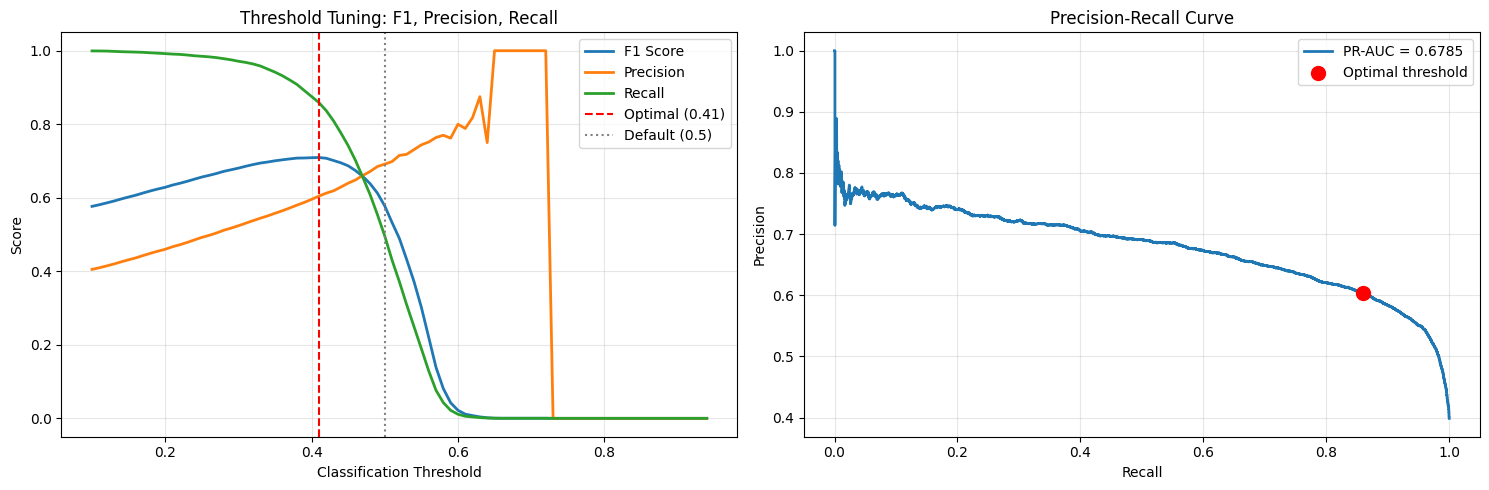

In [17]:
# Visualize threshold tuning and precision-recall curve
from sklearn.metrics import precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: F1, Precision, Recall vs Threshold
axes[0].plot(thresholds, f1_scores, label="F1 Score", linewidth=2)
axes[0].plot(thresholds, precision_scores, label="Precision", linewidth=2)
axes[0].plot(thresholds, recall_scores, label="Recall", linewidth=2)
axes[0].axvline(optimal_threshold, color="red", linestyle="--", label=f"Optimal ({optimal_threshold:.2f})")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Threshold Tuning: F1, Precision, Recall")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
precisions, recalls, threshs = precision_recall_curve(y_true, y_prob)
pr_auc_val = auc(recalls, precisions)
axes[1].plot(recalls, precisions, linewidth=2, label=f"PR-AUC = {pr_auc_val:.4f}")
axes[1].scatter([metrics["recall"]], [metrics["precision"]], color="red", s=100, zorder=5, label=f"Optimal threshold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Selected samples for layer-wise visualization:
- AI-generated sample #2 | true=AI-generated | pred=AI-generated | prob(real)=0.3211
- Real sample #0 | true=Real | pred=Real | prob(real)=0.5260


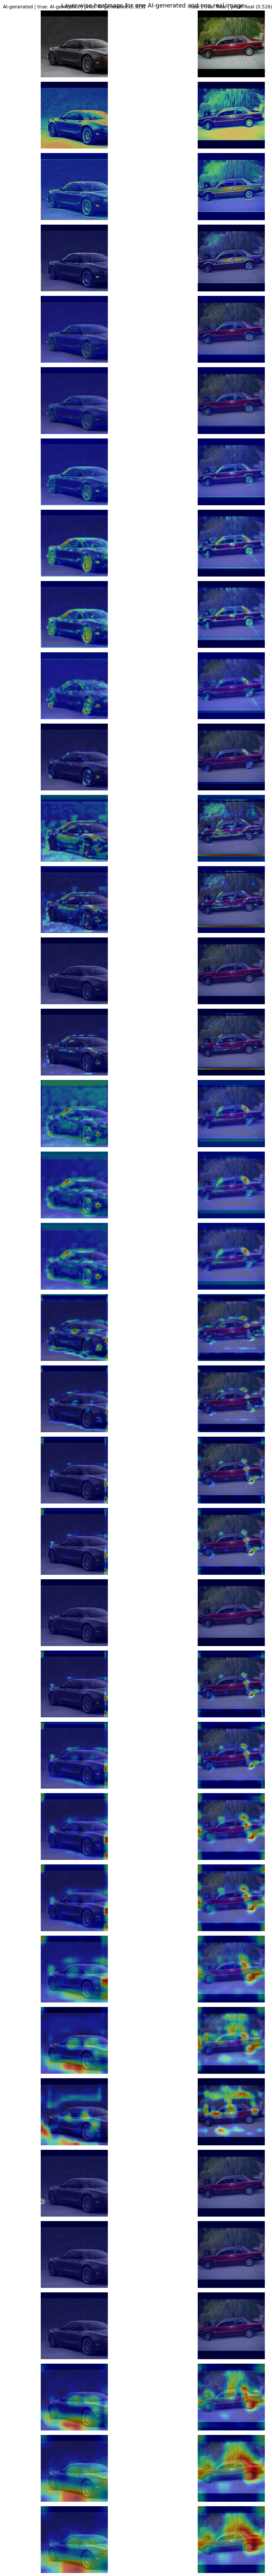

In [18]:
# Layer-wise heatmaps for one AI-generated and one real image

def get_first_example_by_label(hf_split, target_label):
    for index, example in enumerate(hf_split):
        if int(example["label"]) == target_label:
            image = example["image"].convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
            return index, np.asarray(image, dtype=np.uint8), int(example["label"])
    raise ValueError(f"No example found for label {target_label}.")


def preprocess_single_image(image_array):
    image_tensor = tf.convert_to_tensor(image_array, dtype=tf.float32) / 255.0
    return tf.expand_dims(image_tensor, axis=0)


# Spatial layers produce 2D activations that can be visualized as heatmaps.
spatial_layers = [
    layer
    for layer in model.layers
    if hasattr(layer, "output") and len(layer.output.shape) == 4
]

activation_model = tf.keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in spatial_layers],
)


def build_layer_heatmaps(image_tensor):
    activations = activation_model(image_tensor, training=False)
    heatmaps = []

    for activation in activations:
        activation_map = tf.reduce_mean(activation[0], axis=-1)
        activation_map = tf.maximum(activation_map, 0.0)
        activation_map = tf.image.resize(
            activation_map[..., tf.newaxis],
            [IMG_HEIGHT, IMG_WIDTH],
        )
        activation_map = tf.squeeze(activation_map, axis=-1).numpy()

        max_value = float(np.max(activation_map))
        if max_value > 0:
            activation_map = activation_map / max_value

        heatmaps.append(activation_map)

    return heatmaps


label_display = {0: "AI-generated", 1: "Real"}
threshold_used = optimal_threshold if "optimal_threshold" in globals() else 0.5
sample_specs = [("AI-generated", 0), ("Real", 1)]
samples = []

for sample_name, target_label in sample_specs:
    sample_index, image_array, true_label = get_first_example_by_label(test_raw, target_label)
    image_tensor = preprocess_single_image(image_array)
    prediction_prob = float(model.predict(image_tensor, verbose=0)[0, 0])
    predicted_label = int(prediction_prob >= threshold_used)
    heatmaps = build_layer_heatmaps(image_tensor)

    samples.append(
        {
            "name": sample_name,
            "index": sample_index,
            "image": image_array,
            "true_label": true_label,
            "prediction_prob": prediction_prob,
            "predicted_label": predicted_label,
            "heatmaps": heatmaps,
        }
    )

print("Selected samples for layer-wise visualization:")
for sample in samples:
    print(
        f"- {sample['name']} sample #{sample['index']} | true={label_display[sample['true_label']]} | "
        f"pred={label_display[sample['predicted_label']]} | prob(real)={sample['prediction_prob']:.4f}"
    )

fig, axes = plt.subplots(
    len(spatial_layers) + 1,
    2,
    figsize=(14, 2.4 * (len(spatial_layers) + 1)),
    squeeze=False,
)

for col, sample in enumerate(samples):
    axes[0, col].imshow(sample["image"])
    axes[0, col].set_title(
        f"{sample['name']} | true: {label_display[sample['true_label']]} | "
        f"pred: {label_display[sample['predicted_label']]} ({sample['prediction_prob']:.3f})",
        fontsize=11,
    )
    axes[0, col].axis("off")

axes[0, 0].set_ylabel("Original", rotation=0, labelpad=50, va="center")

for row_idx, layer in enumerate(spatial_layers, start=1):
    for col, sample in enumerate(samples):
        ax = axes[row_idx, col]
        ax.imshow(sample["image"])
        ax.imshow(sample["heatmaps"][row_idx - 1], cmap="jet", alpha=0.45, interpolation="bilinear")
        ax.axis("off")

    axes[row_idx, 0].set_ylabel(layer.name, rotation=0, labelpad=50, va="center", fontsize=9)

fig.suptitle("Layer-wise heatmaps for one AI-generated and one real image", fontsize=14, y=0.995)
plt.tight_layout()
plt.show()